In [1]:
import qiskit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino

# Visualize both histograms
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt



# Define Main Paths, Constants

In [ ]:
MAX_HOPS = 2
MIN_HOPS = 1
NUM_SHOTS = 1000

In [3]:
# The nodes of the network
node_names = [0, 1, 2, 3, 4, 5]

# =============================================================================
# FIXED PHYSICAL QUBIT MAPPING
# =============================================================================
# Each network node is assigned to specific physical qubits on FakeFez.
# This ensures consistent noise characteristics across all runs:
# - Node X always uses the same physical qubits regardless of circuit structure
# - When Node X is absent from a circuit, its physical qubits are NOT used by other nodes
#
# Each node needs 9 qubits for the [[5,1,3]] code:
#   - Qubits 0-4: Data + Encoding qubits (the 5 code qubits)
#   - Qubits 5-8: Ancilla qubits for syndrome measurement

NODE_PHYSICAL_QUBITS = {
    0: list(range(0, 9)),      # Node 0 → physical qubits 0-8
    1: list(range(9, 18)),     # Node 1 → physical qubits 9-17
    2: list(range(18, 27)),    # Node 2 → physical qubits 18-26
    3: list(range(27, 36)),    # Node 3 → physical qubits 27-35
    4: list(range(36, 45)),    # Node 4 → physical qubits 36-44
    5: list(range(45, 54)),    # Node 5 → physical qubits 45-53
}

# Physical qubits for path/channel registers (1 qubit per edge for swapping)
PATH_PHYSICAL_QUBITS = {
    (0, 1): [54,55],
    (0, 3): [56],
    (1, 2): [57,58],
    (1, 4): [59],
    (2, 5): [60],
    (3, 4): [61,62],
    (4, 5): [63,64],
}

# PATH_PHYSICAL_QUBITS = {
#     (0, 1): [54],
#     (0, 3): [55],
#     (1, 2): [56],
#     (1, 4): [57],
#     (2, 5): [58],
#     (3, 4): [59],
#     (4, 5): [60],
# }

# Total physical qubits needed: 54 (nodes) + 7 (paths) = 61
TOTAL_QUBITS = len(NODE_PHYSICAL_QUBITS)*9 + sum(len(q) for q in PATH_PHYSICAL_QUBITS.values())

print("Node to Physical Qubit Mapping:")
for node, qubits in NODE_PHYSICAL_QUBITS.items():
    print(f"  Node {node}: physical qubits {qubits[0]}-{qubits[-1]}")
print(f"\nPath Register Physical Qubits: {PATH_PHYSICAL_QUBITS}")
print(f"Total physical qubits used: {TOTAL_QUBITS}")

Node to Physical Qubit Mapping:
  Node 0: physical qubits 0-8
  Node 1: physical qubits 9-17
  Node 2: physical qubits 18-26
  Node 3: physical qubits 27-35
  Node 4: physical qubits 36-44
  Node 5: physical qubits 45-53

Path Register Physical Qubits: {(0, 1): [54, 55], (0, 3): [56], (1, 2): [57, 58], (1, 4): [59], (2, 5): [60], (3, 4): [61, 62], (4, 5): [63, 64]}
Total physical qubits used: 65


In [4]:
# =============================================================================
# NOISE MODEL SETUP (Decoupled from Coupling Constraints)
# =============================================================================
# We extract ONLY the noise model from FakeFez (T1, T2, gate errors, readout errors)
# but do NOT enforce its coupling map. This means:
#   - We get realistic per-qubit noise characteristics
#   - We can connect any qubits we want (no topology constraints)
#   - Physical qubit indices determine which noise profile is applied

fake_backend = FakeFez()
# fake_backend = FakeTorino()
network_channel_noise = NoiseModel.from_backend(fake_backend)

# CRITICAL: FakeFez basis gates - circuits MUST be decomposed to these for noise to apply
# The noise model only has error definitions for these gates!
FEZ_BASIS_GATES = ['cz', 'id', 'rz', 'sx', 'x']

print(f"Noise Model extracted from {fake_backend}")
print(f"  Backend qubits: {fake_backend.num_qubits}")
print(f"  Noise model basis gates: {network_channel_noise.basis_gates}")
print(f"  Gates with noise defined: {network_channel_noise.noise_instructions}")
print(f"\nIMPORTANT: Circuits must be transpiled to basis gates: {FEZ_BASIS_GATES}")
print(f"  SWAP gates will be decomposed to CZ + SX gates for proper noise application")

Noise Model extracted from <qiskit_ibm_runtime.fake_provider.backends.fez.fake_fez.FakeFez object at 0x119a7ef90>
  Backend qubits: 156
  Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Gates with noise defined: ['cz', 'id', 'measure', 'reset', 'sx', 'x']

IMPORTANT: Circuits must be transpiled to basis gates: ['cz', 'id', 'rz', 'sx', 'x']
  SWAP gates will be decomposed to CZ + SX gates for proper noise application


In [5]:
# Verify the physical qubit assignments
print("Physical Qubit Assignments Summary:")
print("-" * 50)
for node in node_names:
    qubits = NODE_PHYSICAL_QUBITS[node]
    print(f"Node {node}: qubits {qubits[0]:2d}-{qubits[-1]:2d} (data={qubits[4]}, ancillas={qubits[5:9]})")

Physical Qubit Assignments Summary:
--------------------------------------------------
Node 0: qubits  0- 8 (data=4, ancillas=[5, 6, 7, 8])
Node 1: qubits  9-17 (data=13, ancillas=[14, 15, 16, 17])
Node 2: qubits 18-26 (data=22, ancillas=[23, 24, 25, 26])
Node 3: qubits 27-35 (data=31, ancillas=[32, 33, 34, 35])
Node 4: qubits 36-44 (data=40, ancillas=[41, 42, 43, 44])
Node 5: qubits 45-53 (data=49, ancillas=[50, 51, 52, 53])


In [6]:
# Verify path register assignments
print("\nPath Register Assignments:")
print("-" * 50)
for edge, qubits in PATH_PHYSICAL_QUBITS.items():
    print(f"Edge {edge}: path qubit(s) = {qubits}")


Path Register Assignments:
--------------------------------------------------
Edge (0, 1): path qubit(s) = [54, 55]
Edge (0, 3): path qubit(s) = [56]
Edge (1, 2): path qubit(s) = [57, 58]
Edge (1, 4): path qubit(s) = [59]
Edge (2, 5): path qubit(s) = [60]
Edge (3, 4): path qubit(s) = [61, 62]
Edge (4, 5): path qubit(s) = [63, 64]


{(0, 1): 1, (1, 2): 1, (0, 3): 1, (1, 4): 1, (2, 5): 1, (3, 4): 1, (4, 5): 1}


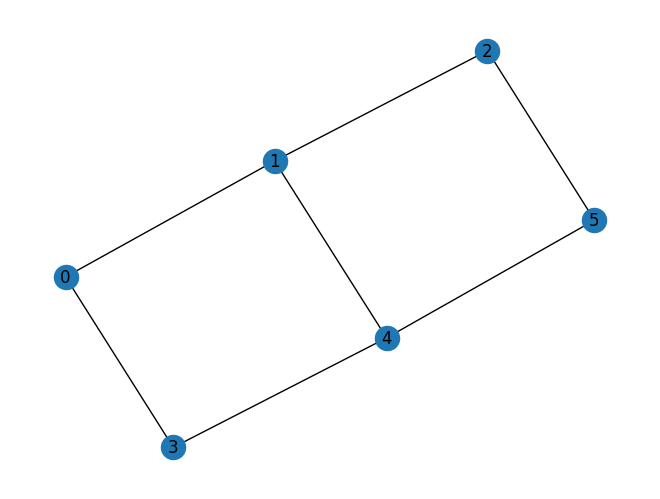

In [7]:
import networkx as nx

network_graph = nx.Graph()
network_graph.add_nodes_from(node_names)
network_graph.add_edges_from([(0, 1), (1, 2), (0, 3), (1, 4), (2, 5), (3, 4), (4, 5)])
nx.draw(network_graph, with_labels=True)

swaps_per_edge = {
    (0, 1): 1,
    (1, 2): 1,
    (0, 3): 1,
    (1, 4): 1,
    (2, 5): 1,
    (3, 4): 1,
    (4, 5): 1
}
print(swaps_per_edge)

In [8]:
# Multi-hop paths:
from itertools import combinations
ALL_HOP_PATHS = []
for pairs in combinations(node_names, 2):
    multi_hop_paths = nx.all_simple_paths(network_graph, source=pairs[0], target=pairs[1], cutoff=MAX_HOPS)
    ALL_HOP_PATHS.extend([x for x in multi_hop_paths if len(x) > MIN_HOPS])

print("All multi-hop paths:", ALL_HOP_PATHS)

All multi-hop paths: [[0, 1], [0, 1, 2], [0, 3], [0, 1, 4], [0, 3, 4], [1, 2], [1, 0, 3], [1, 4, 3], [1, 4], [1, 2, 5], [1, 4, 5], [2, 1, 4], [2, 5, 4], [2, 5], [3, 4], [3, 4, 5], [4, 5]]


# Encoding Circuit

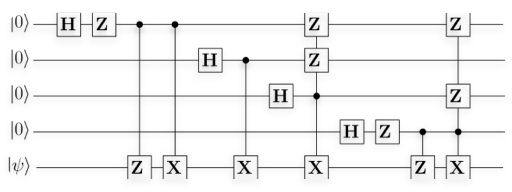

In [9]:
# =============================================================================
# CIRCUIT BUILDING FUNCTIONS (Using Physical Qubits Directly)
# =============================================================================
# These functions build circuits using physical qubit indices from NODE_PHYSICAL_QUBITS.
# This ensures consistent qubit-to-noise mapping across all runs.

# Syndrome-to-correction lookup table for [[5,1,3]] code
# Stabilizers: g1=XZZXI, g2=IXZZX, g3=XIXZZ, g4=ZXIXZ
# Syndrome bits ordered [g1, g2, g3, g4] (ancilla indices 5,6,7,8)
# Correction tuple: (qubit_index, pauli_operator) or None for no error
SYNDROME_TO_CORRECTION = {
    0:  None,        # No error
    1:  (0, 'X'),    # X error on qubit 0  - syndrome 0001
    2:  (2, 'Z'),    # Z error on qubit 2  - syndrome 0010
    3:  (4, 'X'),    # X error on qubit 4  - syndrome 0011
    4:  (4, 'Z'),    # Z error on qubit 4  - syndrome 0100
    5:  (1, 'Z'),    # Z error on qubit 1  - syndrome 0101
    6:  (3, 'X'),    # X error on qubit 3  - syndrome 0110
    7:  (4, 'Y'),    # Y error on qubit 4  - syndrome 0111
    8:  (1, 'X'),    # X error on qubit 1  - syndrome 1000
    9:  (3, 'Z'),    # Z error on qubit 3  - syndrome 1001
    10: (0, 'Z'),    # Z error on qubit 0  - syndrome 1010
    11: (0, 'Y'),    # Y error on qubit 0  - syndrome 1011
    12: (2, 'X'),    # X error on qubit 2  - syndrome 1100
    13: (1, 'Y'),    # Y error on qubit 1  - syndrome 1101
    14: (2, 'Y'),    # Y error on qubit 2  - syndrome 1110
    15: (3, 'Y'),    # Y error on qubit 3  - syndrome 1111
}


def apply_encoding(qc, qubits):
    """
    Apply [[5,1,3]] encoding circuit.
    
    Args:
        qc: QuantumCircuit
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4] where q4 is the data qubit
    """
    qc.h(qubits[0])
    qc.z(qubits[0])
    qc.cz(qubits[0], qubits[4])
    qc.cx(qubits[0], qubits[4])

    qc.h(qubits[1])
    qc.cx(qubits[1], qubits[4])

    qc.h(qubits[2])
    qc.cx(qubits[2], qubits[4])
    qc.cz(qubits[2], qubits[1])
    qc.cz(qubits[2], qubits[0])

    qc.h(qubits[3])
    qc.z(qubits[3])
    qc.cz(qubits[3], qubits[4])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[2])
    qc.cz(qubits[3], qubits[0])


def apply_decoding(qc, qubits):
    """
    Apply [[5,1,3]] decoding circuit (inverse of encoding).
    After decoding, the logical qubit is on qubit[4] (the original data qubit).
    
    Args:
        qc: QuantumCircuit
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4]
    """
    # Reverse of encoding: apply gates in reverse order
    # Each gate is self-inverse (H†=H, Z†=Z, CZ†=CZ, CX†=CX)
    
    # Reverse of qubit 3 block
    qc.cz(qubits[3], qubits[0])
    qc.cz(qubits[3], qubits[2])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[4])
    qc.z(qubits[3])
    qc.h(qubits[3])

    # Reverse of qubit 2 block
    qc.cz(qubits[2], qubits[0])
    qc.cz(qubits[2], qubits[1])
    qc.cx(qubits[2], qubits[4])
    qc.h(qubits[2])

    # Reverse of qubit 1 block
    qc.cx(qubits[1], qubits[4])
    qc.h(qubits[1])

    # Reverse of qubit 0 block
    qc.cx(qubits[0], qubits[4])
    qc.cz(qubits[0], qubits[4])
    qc.z(qubits[0])
    qc.h(qubits[0])


def build_swapping_circuit_syndrome_physical(source, sink, initial_state='0'):
    """
    Build a single-hop syndrome circuit using physical qubit indices.
    
    Args:
        source: Source node ID (0-5)
        sink: Sink node ID (0-5)
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    # Get physical qubit indices for source and sink nodes
    source_qubits = NODE_PHYSICAL_QUBITS[source]  # 9 qubits
    sink_qubits = NODE_PHYSICAL_QUBITS[sink]      # 9 qubits
    
    # Get path qubit(s) for this edge
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
    
    # Create circuit with enough qubits
    qc = QuantumCircuit(TOTAL_QUBITS)
    
    # Add classical register for syndrome measurement
    sink_syndrome_bits = ClassicalRegister(4, name=f'c_syndrome_{sink}')
    qc.add_register(sink_syndrome_bits)
    
    # Qubit roles within each node (indices 0-8 within the node's allocation):
    # 0-3: Encoding qubits for [[5,1,3]] code
    # 4: Data qubit
    # 5-8: Ancilla qubits for syndrome measurement
    
    # Prepare initial state at source (data qubit = index 4)
    if initial_state == '1':
        qc.x(source_qubits[4])

    # Encoding using [[5,1,3]] code
    apply_encoding(qc, source_qubits[:5])
    
    qc.barrier(label='Encoding Complete')
    
    # Swap encoded qubits (0-4) from source to sink via path
    num_path_qubits = len(path_qubits)
    for i in range(5):
        qc.swap(source_qubits[i], path_qubits[0])
        for j in range(num_path_qubits - 1):
            qc.swap(path_qubits[j], path_qubits[j + 1])
        qc.swap(path_qubits[num_path_qubits - 1], sink_qubits[i])
    
    qc.barrier(label='Swapping Path Complete')

    # Syndrome measurement at sink
    stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

    for idx, stabilizer in enumerate(stabilizers):
        ancilla_idx = idx + 5  # Ancillas are at indices 5-8
        qc.h(sink_qubits[ancilla_idx])
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(sink_qubits[ancilla_idx], sink_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(sink_qubits[ancilla_idx], sink_qubits[qubit_idx])
        
        qc.h(sink_qubits[ancilla_idx])
        qc.measure(sink_qubits[ancilla_idx], sink_syndrome_bits[idx])

    return qc


def apply_coherent_correction(qc, data_qubits, ancilla_qubits):
    """
    Apply coherent error correction using ancilla qubits as controls.
    No measurement needed - uses ancilla states directly to control corrections.
    
    Args:
        qc: QuantumCircuit to add corrections to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        ancilla_qubits: List of 4 ancilla qubit indices [a0, a1, a2, a3] for syndromes g1,g2,g3,g4
    """
    # Ancilla mapping: ancilla_qubits[0]=g1, [1]=g2, [2]=g3, [3]=g4
    # Syndrome integer: g1*8 + g2*4 + g3*2 + g4*1
    
    for syndrome_val, correction in SYNDROME_TO_CORRECTION.items():
        if correction is None:
            continue
        
        qubit_idx, pauli = correction
        target = data_qubits[qubit_idx]
        
        # Convert syndrome value to control pattern
        # syndrome_val in binary: bit3=g1, bit2=g2, bit1=g3, bit0=g4
        ctrl_pattern = [(syndrome_val >> (3-i)) & 1 for i in range(4)]
        
        # Build control list with proper polarities
        # For each ancilla: if pattern bit is 0, we need X gate to flip before and after (negative control)
        controls = []
        for i, bit in enumerate(ctrl_pattern):
            controls.append(ancilla_qubits[i])
        
        # Apply X gates to ancillas where we need negative control (bit=0)
        for i, bit in enumerate(ctrl_pattern):
            if bit == 0:
                qc.x(ancilla_qubits[i])
        
        # Apply the correction as multi-controlled gate
        if pauli == 'X':
            qc.mcx(controls, target)
        elif pauli == 'Z':
            # MCZ = H-MCX-H on target
            qc.h(target)
            qc.mcx(controls, target)
            qc.h(target)
        elif pauli == 'Y':
            # Y = iXZ, apply both
            qc.mcx(controls, target)
            qc.h(target)
            qc.mcx(controls, target)
            qc.h(target)
        
        # Undo the X gates on ancillas (restore their state)
        for i, bit in enumerate(ctrl_pattern):
            if bit == 0:
                qc.x(ancilla_qubits[i])


def build_multihop_swapping_circuit_correction_physical(path, initial_state='0', decode_before_measure=True):
    """
    Build a multi-hop circuit with coherent correction.
    
    Two measurement modes controlled by decode_before_measure:
    
    Mode 1 (decode_before_measure=True):
        Pipeline: Encode → Swap → Syndrome → Correct → Decode → Measure qubit[4]
        - Adds decoding gates (more noise after correction)
        - Returns 1-bit measurement
        
    Mode 2 (decode_before_measure=False):
        Pipeline: Encode → Swap → Syndrome → Correct → Measure all 5 qubits
        - No decoding gates (less noise after correction)
        - Returns 5-bit measurement, logical outcome = parity
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2]
        initial_state: '0' or '1'
        decode_before_measure: If True, decode then measure 1 qubit.
                               If False, measure 5 qubits (parity = logical outcome).
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    print(f"Building circuit for path: {path} (decode={decode_before_measure})")
    
    # Create circuit with fixed number of qubits
    qc = QuantumCircuit(TOTAL_QUBITS)
    
    source = path[0]
    sink = path[-1]
    source_qubits = NODE_PHYSICAL_QUBITS[source]
    sink_qubits = NODE_PHYSICAL_QUBITS[sink]
    
    # Add classical register based on measurement mode
    if decode_before_measure:
        logical_bits = ClassicalRegister(1, name='c_logical')
    else:
        logical_bits = ClassicalRegister(5, name='c_logical')
    qc.add_register(logical_bits)
    
    # Prepare initial state at source (data qubit = index 4)
    if initial_state == '1':
        qc.x(source_qubits[4])

    print(f"  Source: Node {source} (physical qubits {source_qubits[0]}-{source_qubits[8]})")
    print(f"  Sink: Node {sink} (physical qubits {sink_qubits[0]}-{sink_qubits[8]})")

    # Encoding using [[5,1,3]] code
    apply_encoding(qc, source_qubits[:5])
    
    qc.barrier(label='Encoding Complete')
    
    # Multi-hop swapping: iterate through each edge in the path
    swap_edges = list(zip(path[:-1], path[1:]))
    print(f"  Swap edges: {swap_edges}")
    
    current_node = source
    for edge_src, edge_dst in swap_edges:
        current_qubits = NODE_PHYSICAL_QUBITS[edge_src]
        next_qubits = NODE_PHYSICAL_QUBITS[edge_dst]
        
        # Get path qubits for this edge
        edge_key = (min(edge_src, edge_dst), max(edge_src, edge_dst))
        path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
        num_path_qubits = len(path_qubits)
        
        # Swap all 5 code qubits from current to next node
        for i in range(5):
            qc.swap(current_qubits[i], path_qubits[0])
            for j in range(num_path_qubits - 1):
                qc.swap(path_qubits[j], path_qubits[j + 1])
            qc.swap(path_qubits[num_path_qubits - 1], next_qubits[i])
        
        current_node = edge_dst

    qc.barrier(label='Swapping Path Complete')

    # Syndrome extraction at sink (without measurement)
    # After H-controlled gates-H, ancilla is |0⟩ if +1 eigenvalue, |1⟩ if -1 eigenvalue
    stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

    for idx, stabilizer in enumerate(stabilizers):
        ancilla_idx = idx + 5
        qc.h(sink_qubits[ancilla_idx])
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(sink_qubits[ancilla_idx], sink_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(sink_qubits[ancilla_idx], sink_qubits[qubit_idx])
        
        qc.h(sink_qubits[ancilla_idx])
        # NO measurement here - ancilla state encodes syndrome

    qc.barrier(label='Syndrome Extracted')

    # Apply coherent correction using ancillas as controls
    data_qubits = [sink_qubits[i] for i in range(5)]
    ancilla_qubits = [sink_qubits[i] for i in range(5, 9)]  # ancillas 5,6,7,8
    apply_coherent_correction(qc, data_qubits, ancilla_qubits)

    qc.barrier(label='Correction Applied')

    if decode_before_measure:
        # MODE 1: Decode then measure single qubit
        apply_decoding(qc, sink_qubits[:5])
        qc.barrier(label='Decoding Complete')
        # Measure only the data qubit (index 4) which now holds the logical state
        qc.measure(sink_qubits[4], logical_bits[0])
    else:
        # MODE 2: Measure all 5 qubits, compute parity in post-processing
        # Logical Z = Z0*Z1*Z2*Z3*Z4, so parity gives logical outcome
        for i in range(5):
            qc.measure(sink_qubits[i], logical_bits[i])

    return qc


def compute_logical_success_rate_parity(counts, expected_logical_state='0'):
    """
    Compute logical success rate from 5-qubit measurement using parity.
    
    For [[5,1,3]] code, logical Z = Z0*Z1*Z2*Z3*Z4 (parity of all bits).
    - Even parity → Logical |0⟩
    - Odd parity  → Logical |1⟩
    
    Args:
        counts: Dictionary of {bitstring: count}
        expected_logical_state: '0' or '1'
    
    Returns:
        success_rate, correct_count, total_count
    """
    correct_count = 0
    total_count = 0
    
    expected_parity = int(expected_logical_state)
    
    for bitstring, count in counts.items():
        total_count += count
        # Compute parity (XOR of all bits)
        parity = bitstring.count('1') % 2
        if parity == expected_parity:
            correct_count += count
    
    success_rate = correct_count / total_count if total_count > 0 else 0
    return success_rate, correct_count, total_count


def compute_logical_success_rate_decoded(counts, expected_logical_state='0'):
    """
    Compute logical success rate from single decoded qubit measurement.
    
    Args:
        counts: Dictionary of {bitstring: count}
        expected_logical_state: '0' or '1'
    
    Returns:
        success_rate, correct_count, total_count
    """
    correct_count = counts.get(expected_logical_state, 0)
    total_count = sum(counts.values())
    success_rate = correct_count / total_count if total_count > 0 else 0
    return success_rate, correct_count, total_count


# Test both modes
print("=" * 70)
print("Testing both measurement modes")
print("=" * 70)

# Mode 1: Decode before measure
circuit_decoded = build_multihop_swapping_circuit_correction_physical([0, 1, 2], initial_state='1', decode_before_measure=True)
print(f"\nMode 1 (Decoded): {circuit_decoded.num_qubits} qubits, {circuit_decoded.num_clbits} classical bits")

# Mode 2: Parity-based
circuit_parity = build_multihop_swapping_circuit_correction_physical([0, 1, 2], initial_state='1', decode_before_measure=False)
print(f"Mode 2 (Parity): {circuit_parity.num_qubits} qubits, {circuit_parity.num_clbits} classical bits")

Testing both measurement modes
Building circuit for path: [0, 1, 2] (decode=True)
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 2 (physical qubits 18-26)
  Swap edges: [(0, 1), (1, 2)]

Mode 1 (Decoded): 65 qubits, 1 classical bits
Building circuit for path: [0, 1, 2] (decode=False)
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 2 (physical qubits 18-26)
  Swap edges: [(0, 1), (1, 2)]
Mode 2 (Parity): 65 qubits, 5 classical bits


In [10]:
# =============================================================================
# Test noiseless simulation of both circuit modes
# =============================================================================
# Transpile to basis gates only (no backend = no qubit count limit)
simulator = AerSimulator(noise_model=None, method='matrix_product_state')

# Test DECODED mode (1 classical bit)
decomposed_decoded = transpile(circuit_decoded, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
print(f"DECODED mode - Gate counts: {decomposed_decoded.count_ops()}")
result_decoded = simulator.run(decomposed_decoded, shots=NUM_SHOTS).result()
counts_decoded = dict(sorted(result_decoded.get_counts().items(), key=lambda x: x[0]))
print(f"  Counts: {counts_decoded}")

# Test PARITY mode (5 classical bits)
decomposed_parity = transpile(circuit_parity, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
print(f"\nPARITY mode - Gate counts: {decomposed_parity.count_ops()}")
result_parity = simulator.run(decomposed_parity, shots=NUM_SHOTS).result()
counts_parity = dict(sorted(result_parity.get_counts().items(), key=lambda x: x[0]))
print(f"  Counts: {counts_parity}")

# Verify logical outcome
success_decoded, _, _ = compute_logical_success_rate_decoded(counts_decoded, expected_logical_state='1')
success_parity, _, _ = compute_logical_success_rate_parity(counts_parity, expected_logical_state='1')
print(f"\nNoiseless success rates (expected |1⟩):")
print(f"  DECODED: {success_decoded:.4f}")
print(f"  PARITY:  {success_parity:.4f}")

DECODED mode - Gate counts: OrderedDict({'rz': 2440, 'sx': 1168, 'cz': 486, 'x': 97, 'barrier': 5, 'measure': 1})
  Counts: {'1': 100}

PARITY mode - Gate counts: OrderedDict({'rz': 2414, 'sx': 1156, 'cz': 476, 'x': 97, 'measure': 5, 'barrier': 4})
  Counts: {'00001': 4, '00010': 8, '00100': 3, '00111': 6, '01000': 4, '01011': 10, '01101': 8, '01110': 3, '10000': 5, '10011': 5, '10101': 8, '10110': 9, '11001': 7, '11010': 11, '11100': 4, '11111': 5}

Noiseless success rates (expected |1⟩):
  DECODED: 1.0000
  PARITY:  1.0000


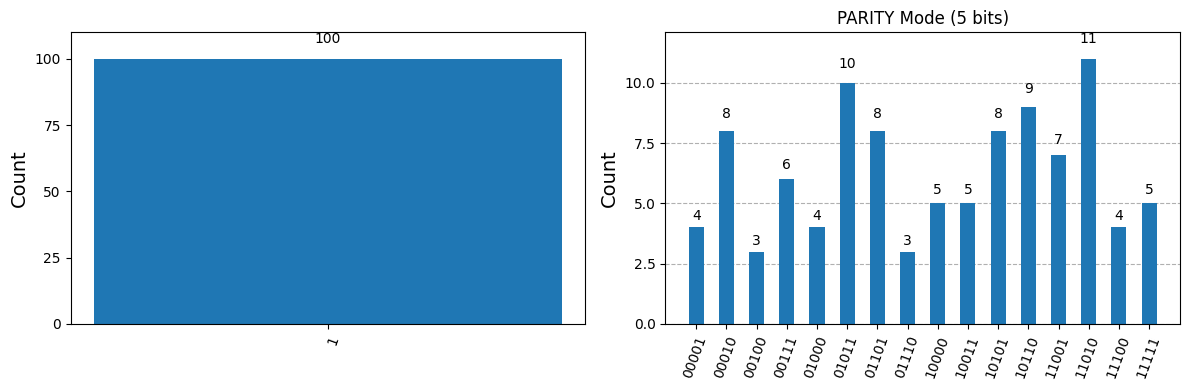

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_histogram(counts_decoded, ax=axes[0], title='DECODED Mode (1 bit)')
plot_histogram(counts_parity, ax=axes[1], title='PARITY Mode (5 bits)')
plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# NOISY SIMULATION (Proper Noise Application)
# =============================================================================
# CRITICAL: Transpile to FakeFez basis gates so noise model applies correctly!
# - basis_gates only (no backend) = no coupling map or qubit count constraints
# - SWAP → 3 CZ + 6 SX gates, all with noise defined

noisy_simulator = AerSimulator(
    noise_model=network_channel_noise,
    method='matrix_product_state'
)

# Transpile both circuits to basis gates for proper noise application
noisy_decoded = transpile(circuit_decoded, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
noisy_parity = transpile(circuit_parity, basis_gates=FEZ_BASIS_GATES, optimization_level=0)

print(f"DECODED circuit: {circuit_decoded.num_qubits} qubits, {circuit_decoded.num_clbits} classical bits")
print(f"  Gate counts: {noisy_decoded.count_ops()}")
print(f"\nPARITY circuit: {circuit_parity.num_qubits} qubits, {circuit_parity.num_clbits} classical bits")
print(f"  Gate counts: {noisy_parity.count_ops()}")
print(f"\nRunning with noise model from FakeFez ({fake_backend.num_qubits} qubits)")

DECODED circuit: 65 qubits, 1 classical bits
  Gate counts: OrderedDict({'rz': 2440, 'sx': 1168, 'cz': 486, 'x': 97, 'barrier': 5, 'measure': 1})

PARITY circuit: 65 qubits, 5 classical bits
  Gate counts: OrderedDict({'rz': 2414, 'sx': 1156, 'cz': 476, 'x': 97, 'measure': 5, 'barrier': 4})

Running with noise model from FakeFez (156 qubits)


In [13]:
# Run noisy simulation on both circuits
print("Running noisy simulations...")
noisy_result_decoded = noisy_simulator.run(noisy_decoded, shots=NUM_SHOTS).result()
noisy_counts_decoded = dict(sorted(noisy_result_decoded.get_counts().items(), key=lambda x: x[0]))

noisy_result_parity = noisy_simulator.run(noisy_parity, shots=NUM_SHOTS).result()
noisy_counts_parity = dict(sorted(noisy_result_parity.get_counts().items(), key=lambda x: x[0]))

print(f"DECODED counts: {noisy_counts_decoded}")
print(f"PARITY counts (top 5): {dict(sorted(noisy_counts_parity.items(), key=lambda x: -x[1])[:5])}")

# Compute success rates
success_decoded, _, _ = compute_logical_success_rate_decoded(noisy_counts_decoded, expected_logical_state='1')
success_parity, _, _ = compute_logical_success_rate_parity(noisy_counts_parity, expected_logical_state='1')
print(f"\nNoisy success rates (expected |1⟩):")
print(f"  DECODED: {success_decoded:.4f}")
print(f"  PARITY:  {success_parity:.4f}")

Running noisy simulations...
DECODED counts: {'0': 11, '1': 89}
PARITY counts (top 5): {'00010': 10, '01101': 7, '01110': 7, '11010': 7, '10101': 6}

Noisy success rates (expected |1⟩):
  DECODED: 0.8900
  PARITY:  0.8000


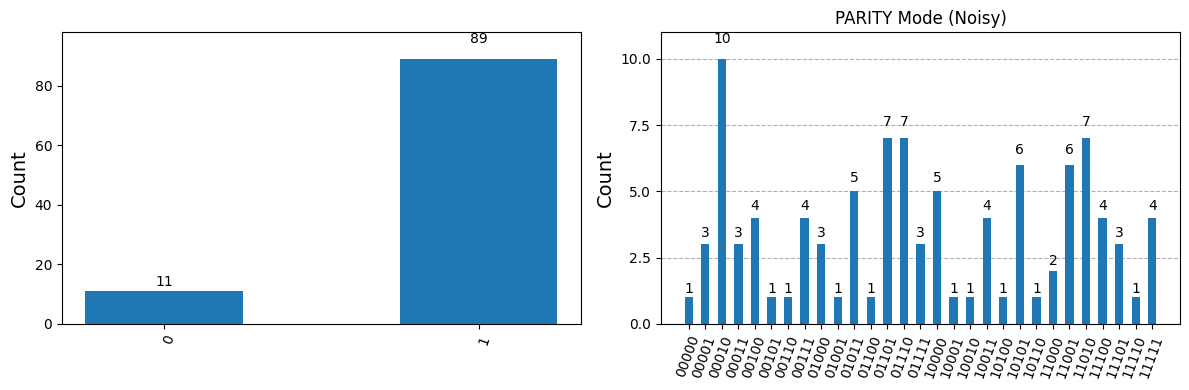

In [14]:
# Visualize noisy histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_histogram(noisy_counts_decoded, ax=axes[0], title='DECODED Mode (Noisy)')
plot_histogram(noisy_counts_parity, ax=axes[1], title='PARITY Mode (Noisy)')
plt.tight_layout()
plt.show()

In [15]:
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type  # Default, will be updated per sample


# 513 Syndrome Data

In [16]:
import numpy as np

# =============================================================================
# 513 LOGICAL QUBIT DATA GENERATION - COMPARING BOTH METHODS
# =============================================================================
# Method 1 (Decoded): Encode → Swap → Syndrome → Correct → Decode → Measure 1 qubit
#   - More gates after correction (decoding adds noise)
#   - Direct logical outcome from measurement
#
# Method 2 (Parity): Encode → Swap → Syndrome → Correct → Measure 5 qubits
#   - Fewer gates after correction (no decoding noise)
#   - Logical outcome = parity of 5-bit measurement

LOGICAL_MEASUREMENT_DATA_DECODED = []
LOGICAL_MEASUREMENT_DATA_PARITY = []

# Create noisy simulator (noise model only, no coupling constraints)
NOISY_AER_SIM = AerSimulator(
    noise_model=network_channel_noise,
    method='matrix_product_state'
)

print("=" * 80)
print("513 LOGICAL QUBIT MEASUREMENT - COMPARING DECODED vs PARITY METHODS")
print("=" * 80)
print(f"Simulator: AerSimulator with FakeFez noise model")
print(f"Basis gates for decomposition: {FEZ_BASIS_GATES}")
print(f"Shots per circuit: {NUM_SHOTS}")
print(f"Total paths to process: {len(ALL_HOP_PATHS)}")
print("=" * 80)

# Summary statistics
decoded_success_rates = []
parity_success_rates = []

for path_idx, path in enumerate(ALL_HOP_PATHS):
    print(f"\n[{path_idx + 1}/{len(ALL_HOP_PATHS)}] Path: {path}")
    path_edges = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
    
    # =========================================================================
    # METHOD 1: DECODED (Correct → Decode → Measure 1 qubit)
    # =========================================================================
    circuit_decoded = build_multihop_swapping_circuit_correction_physical(
        path, initial_state='0', decode_before_measure=True
    )
    decomposed_decoded = transpile(circuit_decoded, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
    result_decoded = NOISY_AER_SIM.run(decomposed_decoded, shots=NUM_SHOTS).result()
    counts_decoded = result_decoded.get_counts()
    
    success_decoded, correct_decoded, total_decoded = compute_logical_success_rate_decoded(
        counts_decoded, expected_logical_state='0'
    )
    decoded_success_rates.append(success_decoded)
    
    # Build histogram (2 elements for 1 qubit)
    histogram_decoded = np.zeros(2, dtype=np.float32)
    for bitstring, count in counts_decoded.items():
        idx = int(bitstring, 2)
        histogram_decoded[idx] = count
    
    # =========================================================================
    # METHOD 2: PARITY (Correct → Measure 5 qubits → Compute parity)
    # =========================================================================
    circuit_parity = build_multihop_swapping_circuit_correction_physical(
        path, initial_state='0', decode_before_measure=False
    )
    decomposed_parity = transpile(circuit_parity, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
    result_parity = NOISY_AER_SIM.run(decomposed_parity, shots=NUM_SHOTS).result()
    counts_parity = result_parity.get_counts()
    
    success_parity, correct_parity, total_parity = compute_logical_success_rate_parity(
        counts_parity, expected_logical_state='0'
    )
    parity_success_rates.append(success_parity)
    
    # Build histogram (32 elements for 5 qubits)
    histogram_parity = np.zeros(32, dtype=np.float32)
    for bitstring, count in counts_parity.items():
        idx = int(bitstring, 2)
        histogram_parity[idx] = count
    
    # =========================================================================
    # COMPARISON
    # =========================================================================
    diff = success_parity - success_decoded
    better = "PARITY" if diff > 0 else ("DECODED" if diff < 0 else "TIE")
    
    print(f"  Path edges: {path_edges}")
    print(f"  DECODED:  {success_decoded:.4f} ({int(correct_decoded)}/{int(total_decoded)}) | counts: {counts_decoded}")
    print(f"  PARITY:   {success_parity:.4f} ({int(correct_parity)}/{int(total_parity)}) | top 3: {dict(sorted(counts_parity.items(), key=lambda x: -x[1])[:3])}")
    print(f"  Δ = {diff:+.4f} → {better} wins")
    
    # Store results
    LOGICAL_MEASUREMENT_DATA_DECODED.append(TimeAwareMeasurement(
        path_edges=path_edges,
        histogram=histogram_decoded,
        duration=0.0,
        latency_stats={'success_rate': success_decoded, 'method': 'decoded'},
        code_type='513_decoded'
    ))
    
    LOGICAL_MEASUREMENT_DATA_PARITY.append(TimeAwareMeasurement(
        path_edges=path_edges,
        histogram=histogram_parity,
        duration=0.0,
        latency_stats={'success_rate': success_parity, 'method': 'parity'},
        code_type='513_parity'
    ))

# =========================================================================
# SUMMARY STATISTICS
# =========================================================================
print(f"\n{'=' * 80}")
print("SUMMARY: DECODED vs PARITY")
print(f"{'=' * 80}")
print(f"Total paths evaluated: {len(ALL_HOP_PATHS)}")
print(f"\nDECODED Method (Correct → Decode → Measure 1 qubit):")
print(f"  Mean success rate: {np.mean(decoded_success_rates):.4f}")
print(f"  Std success rate:  {np.std(decoded_success_rates):.4f}")
print(f"  Min/Max: {np.min(decoded_success_rates):.4f} / {np.max(decoded_success_rates):.4f}")

print(f"\nPARITY Method (Correct → Measure 5 qubits → Parity):")
print(f"  Mean success rate: {np.mean(parity_success_rates):.4f}")
print(f"  Std success rate:  {np.std(parity_success_rates):.4f}")
print(f"  Min/Max: {np.min(parity_success_rates):.4f} / {np.max(parity_success_rates):.4f}")

avg_diff = np.mean(parity_success_rates) - np.mean(decoded_success_rates)
parity_wins = sum(1 for p, d in zip(parity_success_rates, decoded_success_rates) if p > d)
decoded_wins = sum(1 for p, d in zip(parity_success_rates, decoded_success_rates) if d > p)
ties = len(ALL_HOP_PATHS) - parity_wins - decoded_wins

print(f"\nComparison:")
print(f"  Average difference (Parity - Decoded): {avg_diff:+.4f}")
print(f"  Parity wins: {parity_wins}/{len(ALL_HOP_PATHS)}")
print(f"  Decoded wins: {decoded_wins}/{len(ALL_HOP_PATHS)}")
print(f"  Ties: {ties}/{len(ALL_HOP_PATHS)}")

overall_winner = "PARITY" if avg_diff > 0.001 else ("DECODED" if avg_diff < -0.001 else "TIE")
print(f"\n  >>> OVERALL WINNER: {overall_winner} <<<")
print(f"{'=' * 80}")

513 LOGICAL QUBIT MEASUREMENT - COMPARING DECODED vs PARITY METHODS
Simulator: AerSimulator with FakeFez noise model
Basis gates for decomposition: ['cz', 'id', 'rz', 'sx', 'x']
Shots per circuit: 100
Total paths to process: 17

[1/17] Path: [0, 1]
Building circuit for path: [0, 1] (decode=True)
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 1 (physical qubits 9-17)
  Swap edges: [(0, 1)]
Building circuit for path: [0, 1] (decode=False)
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 1 (physical qubits 9-17)
  Swap edges: [(0, 1)]
  Path edges: [(0, 1)]
  DECODED:  0.8800 (88/100) | counts: {'1': 12, '0': 88}
  PARITY:   0.8500 (85/100) | top 3: {'10100': 9, '00101': 9, '11000': 8}
  Δ = -0.0300 → DECODED wins

[2/17] Path: [0, 1, 2]
Building circuit for path: [0, 1, 2] (decode=True)
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 2 (physical qubits 18-26)
  Swap edges: [(0, 1), (1, 2)]
Building circuit for path: [0, 1, 2] (decode=False)
  Source: Node 0 (physical qubits 0

# Ground Truth Data

In [17]:
# =============================================================================
# GROUND TRUTH CIRCUIT (Using Physical Qubits)
# =============================================================================

def build_swapping_circuit_ground_truth_physical(source, sink, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport using physical qubit indices.
    
    This circuit transports a single (unencoded) qubit from source to sink
    and measures in the specified basis to determine error rates.
    
    Args:
        source: Source node ID (0-5)
        sink: Sink node ID (0-5)
        initial_state: '0' or '1'
        measurement_basis: 'X', 'Y', or 'Z'
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    # Get physical qubit indices
    source_qubits = NODE_PHYSICAL_QUBITS[source]
    sink_qubits = NODE_PHYSICAL_QUBITS[sink]
    
    # Get path qubit(s) for this edge
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS)
    
    # Data qubit is at index 4 within each node's allocation
    source_qubit = source_qubits[4]
    sink_qubit = sink_qubits[4]
    
    # Prepare initial state
    if initial_state == '1':
        qc.x(source_qubit)

    # Rotate to measurement basis if needed
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)        
        qc.s(source_qubit)

    # Swapping path from source to sink
    num_path_qubits = len(path_qubits)
    qc.swap(source_qubit, path_qubits[0])
    for j in range(num_path_qubits - 1):
        qc.swap(path_qubits[j], path_qubits[j + 1])
    qc.swap(path_qubits[num_path_qubits - 1], sink_qubit)
    
    # Add classical register for measurement
    creg = ClassicalRegister(1, name='c_data')
    qc.add_register(creg)

    # Rotate back before measurement
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)    

    qc.measure(sink_qubit, creg[0])

    return qc

Ground truth circuit: Node 0 -> Node 1
  Source data qubit: 4
  Sink data qubit: 13
  Path qubit: [54, 55]


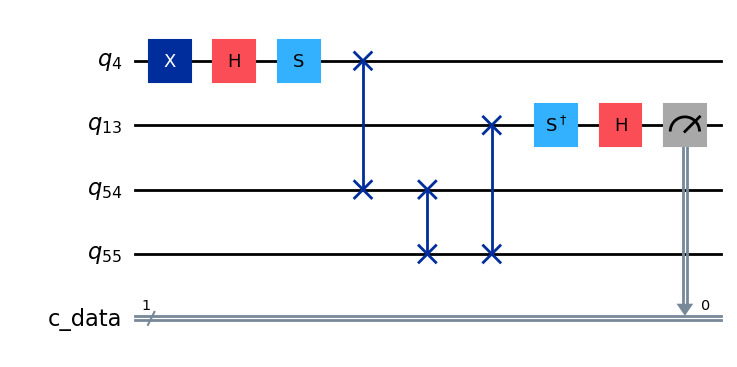

In [18]:
# Test ground truth circuit with physical qubits
a_to_b_circuit = build_swapping_circuit_ground_truth_physical(0, 1, measurement_basis='Y', initial_state='1')
print(f"Ground truth circuit: Node 0 -> Node 1")
print(f"  Source data qubit: {NODE_PHYSICAL_QUBITS[0][4]}")
print(f"  Sink data qubit: {NODE_PHYSICAL_QUBITS[1][4]}")
print(f"  Path qubit: {PATH_PHYSICAL_QUBITS[(0, 1)]}")
a_to_b_circuit.draw('mpl', fold=-1, idle_wires=False)

Circuit qubits: 65
Decomposed gate counts: OrderedDict({'sx': 20, 'cz': 9, 'rz': 6, 'x': 1, 'measure': 1})


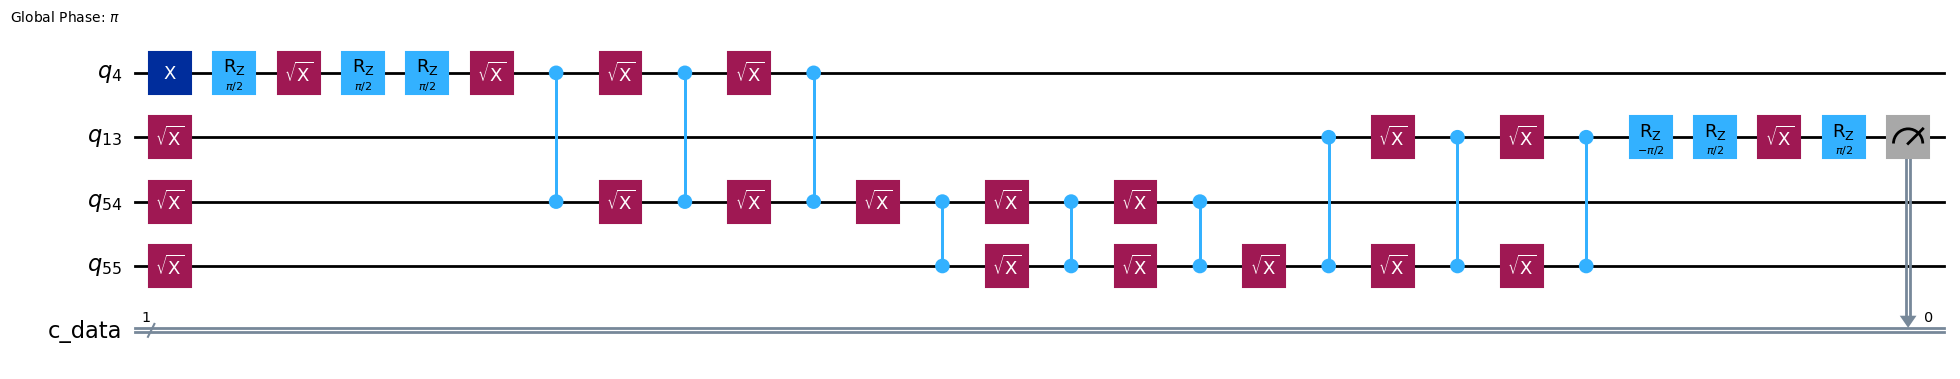

In [19]:
# Transpile to basis gates for proper noise application
decomposed_gt_circuit = transpile(a_to_b_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
print(f"Circuit qubits: {decomposed_gt_circuit.num_qubits}")
print(f"Decomposed gate counts: {decomposed_gt_circuit.count_ops()}")
decomposed_gt_circuit.draw('mpl', fold=-1, idle_wires=False)

In [20]:
# Run decomposed circuit on noisy simulator
noisy_result = noisy_simulator.run(decomposed_gt_circuit, shots=NUM_SHOTS).result()
noisy_counts = dict(sorted(noisy_result.get_counts().items(), key=lambda x: x[0]))
print(noisy_counts)

{'0': 1, '1': 99}


In [21]:
from typing import Dict


def calculate_exact_pauli_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    y_basis_counts: Dict[str, int],
    expected_state: str = '0'
) -> Dict[str, float]:
    """
    Calculate exact X, Y, and Z error rates using full quantum state tomography.
    
    Requires three independent measurement runs in different bases to solve
    the system of equations for Pauli error probabilities.
    
    Theory:
        - Z-basis measurement detects: E_z = P(X) + P(Y)
        - X-basis measurement detects: E_x = P(Z) + P(Y)
        - Y-basis measurement detects: E_y = P(X) + P(Z)
    
    Solving this system:
        P(X) = (E_z + E_y - E_x) / 2
        P(Y) = (E_z + E_x - E_y) / 2
        P(Z) = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: Measurement counts from Z-basis run (detects X and Y errors)
                       e.g., {'0': 850, '1': 50}
        x_basis_counts: Measurement counts from X-basis run (detects Z and Y errors)
                       e.g., {'0': 820, '1': 60}
        y_basis_counts: Measurement counts from Y-basis run (detects X and Z errors)
                       e.g., {'0': 800, '1': 70}
        expected_state: Expected outcome without errors ('0' or '1')
    
    Returns:
        Dictionary with exact error rates:
        {
            'PX': float,  # X error probability
            'PY': float,  # Y error probability
            'PZ': float,  # Z error probability
            'E_z': float, # Raw Z-basis error rate
            'E_x': float, # Raw X-basis error rate
            'E_y': float, # Raw Y-basis error rate
            'total_shots': dict
        }
    """
    
    def get_error_rate(counts: Dict[str, int], correct_label: str) -> float:
        """Calculate the total error rate for a measurement basis."""
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        
        correct_shots = counts.get(correct_label, 0)
        return 1.0 - (correct_shots / total_shots)
    
    # Calculate observed error rates in each basis
    E_z = get_error_rate(z_basis_counts, expected_state)  # P(X) + P(Y)
    E_x = get_error_rate(x_basis_counts, expected_state)  # P(Z) + P(Y)
    E_y = get_error_rate(y_basis_counts, expected_state)  # P(X) + P(Z)
    
    # Solve the system of linear equations
    px = 0.5 * (E_z + E_y - E_x)
    py = 0.5 * (E_z + E_x - E_y)
    pz = 0.5 * (E_x + E_y - E_z)
    
    # Clean up small negatives due to statistical noise
    return {
        'p_x': max(0.0, px),
        'p_y': max(0.0, py),
        'p_z': max(0.0, pz),
        'E_z': E_z,
        'E_x': E_x,
        'E_y': E_y,
        'total_shots': {
            'z_basis': sum(z_basis_counts.values()),
            'x_basis': sum(x_basis_counts.values()),
            'y_basis': sum(y_basis_counts.values())
        }
    }



In [22]:
# =============================================================================
# GROUND TRUTH DATA GENERATION
# =============================================================================
# Generate Pauli error rates for each edge using physical qubit mapping
# CRITICAL: Transpile to basis gates for proper noise application!

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION")
print("=" * 70)
print(f"Using physical qubit mapping with basis gate decomposition")
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"Edges to process: {list(network_graph.edges())}")
print("=" * 70)

for edge in network_graph.edges():
    print(f"\nEdge {edge}:")
    print(f"  Source qubits: {NODE_PHYSICAL_QUBITS[edge[0]][0]}-{NODE_PHYSICAL_QUBITS[edge[0]][-1]}")
    print(f"  Sink qubits: {NODE_PHYSICAL_QUBITS[edge[1]][0]}-{NODE_PHYSICAL_QUBITS[edge[1]][-1]}")
    
    # Build circuits using physical qubit mapping
    circuit_Z = build_swapping_circuit_ground_truth_physical(edge[0], edge[1], measurement_basis='Z')
    circuit_X = build_swapping_circuit_ground_truth_physical(edge[0], edge[1], measurement_basis='X')
    circuit_Y = build_swapping_circuit_ground_truth_physical(edge[0], edge[1], measurement_basis='Y')

    # CRITICAL: Transpile to basis gates for proper noise application
    decomposed_Z = transpile(circuit_Z, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
    decomposed_X = transpile(circuit_X, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
    decomposed_Y = transpile(circuit_Y, basis_gates=FEZ_BASIS_GATES, optimization_level=0)

    print("  Running Z-basis measurement...", end=' | ')
    counts_Z = dict(sorted(NOISY_AER_SIM.run(decomposed_Z, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running X-basis measurement...", end=' | ')
    counts_X = dict(sorted(NOISY_AER_SIM.run(decomposed_X, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running Y-basis measurement...")
    counts_Y = dict(sorted(NOISY_AER_SIM.run(decomposed_Y, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))

    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )

    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"  Pauli Errors: PX={error_rates['p_x']:.6f}, PY={error_rates['p_y']:.6f}, PZ={error_rates['p_z']:.6f}")
    print(f"  Raw error rates: E_x={error_rates['E_x']:.6f}, E_y={error_rates['E_y']:.6f}, E_z={error_rates['E_z']:.6f}")

print(f"\n{'=' * 70}")
print("Ground truth data collection complete")
print(f"{'=' * 70}")

GROUND TRUTH DATA GENERATION
Using physical qubit mapping with basis gate decomposition
Basis gates: ['cz', 'id', 'rz', 'sx', 'x']
Edges to process: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]

Edge (0, 1):
  Source qubits: 0-8
  Sink qubits: 9-17
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.005000, PY=0.005000, PZ=0.000000
  Raw error rates: E_x=0.000000, E_y=0.000000, E_z=0.010000

Edge (0, 3):
  Source qubits: 0-8
  Sink qubits: 27-35
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.005000, PY=0.005000, PZ=0.005000
  Raw error rates: E_x=0.010000, E_y=0.010000, E_z=0.010000

Edge (1, 2):
  Source qubits: 9-17
  Sink qubits: 18-26
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.000000, PY=0.010000, PZ=0.000000
  Raw error rates: E_x=0.010000, E_y=0.000000, 